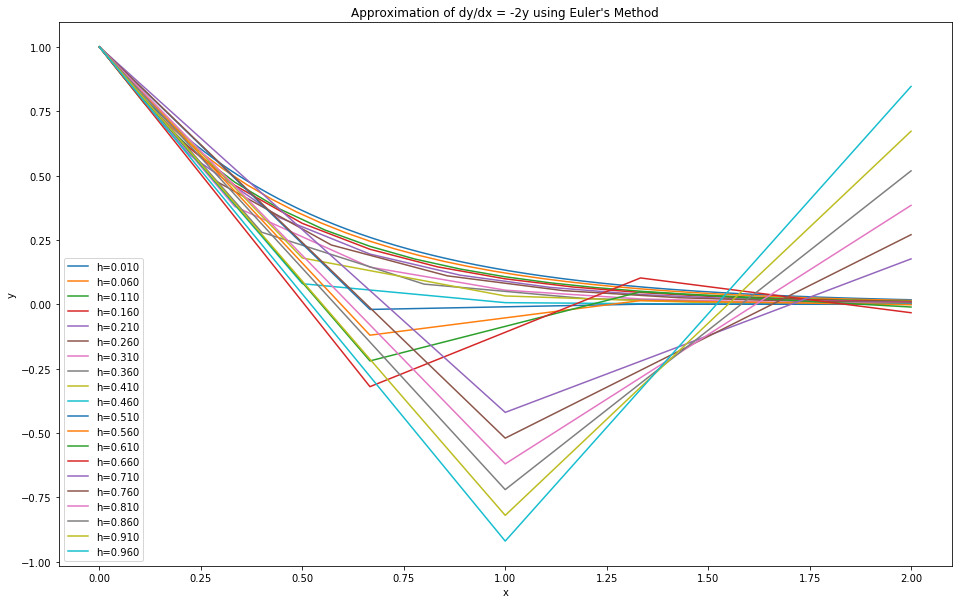

In [3]:
import numpy as np
import matplotlib.pyplot as plt



# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y


# Exact solution for reference
def exact_solution(x):
    return np.exp(-2 * x)


# Define parameters
step_sizes = np.arange(0.01, 1.01, 0.05)  # step size
x_start, x_end = 0, 2
plt.figure(figsize=(16, 10))

runs = []

for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1


    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
        
    runs.append((h, x_values, y_values))
    plt.plot(x_values, y_values, label=f"h={h:.3f}")
    
    
h_ref, x_ref, y_ref = runs[0]



# Plot the results
plt.xlabel('x')
plt.ylabel('y')

plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend() 
plt.show()

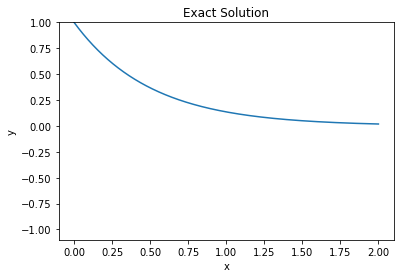

In [4]:
test = np.linspace(0,2,1000)

plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-1.1)
plt.plot(test, exact_solution(test))
plt.title("Exact Solution")
plt.show()

Hey pretty close.

In [5]:
for h, x_vals, y_vals in runs:
    # Interpolate current run onto reference x-values
    y_interp = np.interp(x_ref, x_vals, y_vals) #we have to do this bc each run generates a differing x-axis grid

    # Pointwise error vs first run
    error = np.abs(y_interp - y_ref)

    # Total accumulated error
    total_error = np.sum(error)

    print(f"\nRun with step size h = {h:.2f}")
    print("x\t\tCurrent Run\tFirst Run\tError")
    for x, y_curr, y_first, err in zip(x_ref, y_interp, y_ref, error): #this was ChatGPT i didn't know how to print out everthing cleanly
        print(f"{x:.2f}\t\t{y_curr:.8f}\t{y_first:.8f}\t{err:.8f}")

    print(f"Total accumulated error for h = {h:.2f}: {total_error:.8f}")
    print("-" * 70)


Run with step size h = 0.01
x		Current Run	First Run	Error
0.00		1.00000000	1.00000000	0.00000000
0.01		0.98000000	0.98000000	0.00000000
0.02		0.96040000	0.96040000	0.00000000
0.03		0.94119200	0.94119200	0.00000000
0.04		0.92236816	0.92236816	0.00000000
0.05		0.90392080	0.90392080	0.00000000
0.06		0.88584238	0.88584238	0.00000000
0.07		0.86812553	0.86812553	0.00000000
0.08		0.85076302	0.85076302	0.00000000
0.09		0.83374776	0.83374776	0.00000000
0.10		0.81707281	0.81707281	0.00000000
0.11		0.80073135	0.80073135	0.00000000
0.12		0.78471672	0.78471672	0.00000000
0.13		0.76902239	0.76902239	0.00000000
0.14		0.75364194	0.75364194	0.00000000
0.15		0.73856910	0.73856910	0.00000000
0.16		0.72379772	0.72379772	0.00000000
0.17		0.70932177	0.70932177	0.00000000
0.18		0.69513533	0.69513533	0.00000000
0.19		0.68123262	0.68123262	0.00000000
0.20		0.66760797	0.66760797	0.00000000
0.21		0.65425581	0.65425581	0.00000000
0.22		0.64117070	0.64117070	0.00000000
0.23		0.62834728	0.62834728	0.00000000
0.24

1.52		0.00049316	0.04638350	0.04589034
1.53		0.00048374	0.04545583	0.04497209
1.54		0.00047432	0.04454671	0.04407240
1.55		0.00046490	0.04365578	0.04319088
1.56		0.00045548	0.04278266	0.04232719
1.57		0.00044605	0.04192701	0.04148095
1.58		0.00043663	0.04108847	0.04065184
1.59		0.00042721	0.04026670	0.03983949
1.60		0.00041779	0.03946137	0.03904357
1.61		0.00040837	0.03867214	0.03826377
1.62		0.00039895	0.03789870	0.03749975
1.63		0.00038953	0.03714072	0.03675119
1.64		0.00038011	0.03639791	0.03601780
1.65		0.00037069	0.03566995	0.03529926
1.66		0.00036127	0.03495655	0.03459528
1.67		0.00035185	0.03425742	0.03390557
1.68		0.00034243	0.03357227	0.03322985
1.69		0.00033300	0.03290083	0.03256782
1.70		0.00032358	0.03224281	0.03191922
1.71		0.00031416	0.03159795	0.03128379
1.72		0.00030474	0.03096599	0.03066125
1.73		0.00029532	0.03034667	0.03005135
1.74		0.00028590	0.02973974	0.02945384
1.75		0.00027648	0.02914495	0.02886847
1.76		0.00026706	0.02856205	0.02829499
1.77		0.00025764	0.027990

1.84		0.43361600	0.02429953	0.40931647
1.85		0.44854000	0.02381354	0.42472646
1.86		0.46346400	0.02333727	0.44012673
1.87		0.47838800	0.02287053	0.45551747
1.88		0.49331200	0.02241312	0.47089888
1.89		0.50823600	0.02196485	0.48627115
1.90		0.52316000	0.02152556	0.50163444
1.91		0.53808400	0.02109505	0.51698895
1.92		0.55300800	0.02067314	0.53233486
1.93		0.56793200	0.02025968	0.54767232
1.94		0.58285600	0.01985449	0.56300151
1.95		0.59778000	0.01945740	0.57832260
1.96		0.61270400	0.01906825	0.59363575
1.97		0.62762800	0.01868688	0.60894112
1.98		0.64255200	0.01831315	0.62423885
1.99		0.65747600	0.01794688	0.63952912
2.00		0.67240000	0.01758795	0.65481205
Total accumulated error for h = 0.91: 75.24155356
----------------------------------------------------------------------

Run with step size h = 0.96
x		Current Run	First Run	Error
0.00		1.00000000	1.00000000	0.00000000
0.01		0.98080000	0.98000000	0.00080000
0.02		0.96160000	0.96040000	0.00120000
0.03		0.94240000	0.94119200	0.00120800


as we can see, error grows as step sizes get bigger.